In [1]:
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import StepLR
from torch.optim.lr_scheduler import ReduceLROnPlateau

from models.vae_gpt import *
from train.trainer.Trainer_GPT import Trainer
from data.preprocessing.pipeline import Pipeline
from data.datasets.universal_dataset import CVADataset
from data.preprocessing.splitter import select_test_inh
from utils.paths import get_project_path

import os

In [2]:
def load_data(drop_inhib: str):
    prep = Pipeline(
        num_cycle=[1, 2, 3, 4], 
        inhibitor_name="all", 
        split="all",
        norm_feat=True
    )
    data = prep.full_data

    train_data, valid_data = select_test_inh(data, drop_inhib)
    
    return train_data, valid_data

In [3]:
INHIBITOR_NAME = "2-mercaptobenzimidazole"
normalize = False

train, val = load_data(drop_inhib=INHIBITOR_NAME)

train_dataset = CVADataset(train, normalize=normalize)
test_dataset = CVADataset(val, normalize=normalize)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

In [4]:
if torch.cuda.is_available():
    device = "cuda:0"
else:
    device = "cpu"

vae = GPT(
    cond_dim=41,
    seq_len=968,
    d_model=64,
    nhead=1,
    num_layers=1,
    dropout=0.3
).to(device)

opt_vae = torch.optim.Adam(vae.parameters(), lr=1e-3)
scheduler = StepLR(opt_vae, step_size=50, gamma=0.15)

train_denormalize_fn = None
val_denormalize_fn = None

if normalize:
    train_denormalize_fn = train_dataset.denormalize
    val_denormalize_fn = test_dataset.denormalize

/home/smirnov@dohod.local/Desktop/electrochem-digital-twins/.venv/lib/python3.13/site-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


In [5]:
vae.y_start_emb

Parameter containing:
tensor([[-0.0183,  0.0006,  0.0179,  0.0021,  0.0037,  0.0246,  0.0007, -0.0068,
         -0.0190, -0.0157,  0.0001,  0.0081, -0.0074, -0.0070, -0.0046, -0.0018,
         -0.0123,  0.0004, -0.0079,  0.0102,  0.0074, -0.0022,  0.0017,  0.0005,
         -0.0116, -0.0041,  0.0096,  0.0054,  0.0061, -0.0038,  0.0070, -0.0128,
         -0.0006,  0.0054, -0.0038,  0.0033, -0.0103,  0.0033,  0.0056,  0.0063,
         -0.0047, -0.0059, -0.0050,  0.0183,  0.0019, -0.0186, -0.0159,  0.0013,
         -0.0050,  0.0040,  0.0150,  0.0225, -0.0035,  0.0118,  0.0013,  0.0082,
         -0.0035, -0.0090, -0.0002,  0.0076, -0.0099, -0.0073,  0.0033,  0.0155]],
       device='cuda:0', requires_grad=True)

In [6]:
num_epoch = 251

trainer = Trainer(
    model=vae,
    loss_fn=vae_loss,
    epochs=num_epoch,
    optimizer=opt_vae,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,
    path_to_save_plots=os.path.join(get_project_path(), "reports", "gpt", INHIBITOR_NAME),
    path_to_save_models=os.path.join(get_project_path(), "models", "gpt", INHIBITOR_NAME, "best_model.pt"),
    path_to_save_tables=os.path.join(get_project_path(), "reports", "gpt", INHIBITOR_NAME),
    scheduler=scheduler,
    train_denorm_fn=train_denormalize_fn,
    val_denorm_fn=val_denormalize_fn,
    seed=42
)

In [7]:
trainer.train_model()

Epoch 000 — Train Loss: 0.284265, Val Loss: 0.128728
Epoch 001 — Train Loss: 0.103471, Val Loss: 0.053839
Epoch 002 — Train Loss: 0.055703, Val Loss: 0.031680
Epoch 003 — Train Loss: 0.039119, Val Loss: 0.025382
Epoch 004 — Train Loss: 0.030661, Val Loss: 0.018330
Epoch 005 — Train Loss: 0.025314, Val Loss: 0.015236
Epoch 006 — Train Loss: 0.021824, Val Loss: 0.013652
Epoch 007 — Train Loss: 0.019222, Val Loss: 0.012614
Epoch 008 — Train Loss: 0.017263, Val Loss: 0.011603
Epoch 009 — Train Loss: 0.015623, Val Loss: 0.010821
Epoch 010 — Train Loss: 0.014329, Val Loss: 0.010132
Epoch 011 — Train Loss: 0.013272, Val Loss: 0.009906
Epoch 012 — Train Loss: 0.012396, Val Loss: 0.009138
Epoch 013 — Train Loss: 0.011684, Val Loss: 0.009057
Epoch 014 — Train Loss: 0.011040, Val Loss: 0.008675
Epoch 015 — Train Loss: 0.010470, Val Loss: 0.008255
Epoch 016 — Train Loss: 0.009979, Val Loss: 0.008084
Epoch 017 — Train Loss: 0.009503, Val Loss: 0.007694
Epoch 018 — Train Loss: 0.009097, Val Loss: 0.

In [8]:
vae.y_start_emb

Parameter containing:
tensor([[-0.0250, -0.0052,  0.0186,  0.0002,  0.0045,  0.0127, -0.0033,  0.0045,
         -0.0226, -0.0082, -0.0064,  0.0130,  0.0056,  0.0020,  0.0047,  0.0104,
         -0.0056, -0.0103, -0.0034, -0.0123,  0.0034,  0.0008,  0.0054,  0.0089,
         -0.0150, -0.0268, -0.0162,  0.0109,  0.0009, -0.0132,  0.0290,  0.0024,
         -0.0067,  0.0118, -0.0015,  0.0359, -0.0128, -0.0026, -0.0137,  0.0016,
          0.0078,  0.0195, -0.0020,  0.0312,  0.0247, -0.0326, -0.0166, -0.0009,
         -0.0064, -0.0157,  0.0245,  0.0135, -0.0053,  0.0168,  0.0105,  0.0182,
         -0.0055,  0.0010, -0.0125,  0.0045, -0.0215, -0.0157,  0.0100,  0.0258]],
       device='cuda:0', requires_grad=True)

In [9]:
import matplotlib.pyplot as plt

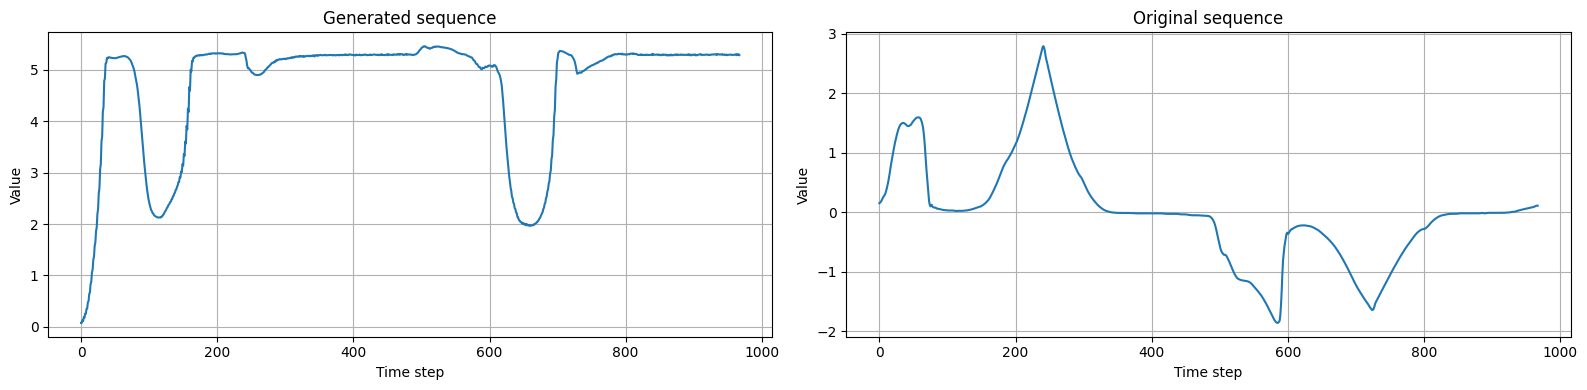

In [10]:
generated_seq = vae.generate(test_dataset[0]['features'].unsqueeze(0).to(device)).squeeze(0).cpu().numpy()  # [968]
test_seq = test_dataset[0]['vah'].cpu().numpy()

fig, axs = plt.subplots(1, 2, figsize=(16, 4))

axs[0].plot(generated_seq)
axs[0].set_title("Generated sequence")
axs[0].set_xlabel("Time step")
axs[0].set_ylabel("Value")
axs[0].grid(True)

axs[1].plot(test_seq)
axs[1].set_title("Original sequence")
axs[1].set_xlabel("Time step")
axs[1].set_ylabel("Value")
axs[1].grid(True)

plt.tight_layout()
plt.show()